In [1]:
import pandas as pd

df = pd.read_csv("reduced_dataset.csv")
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,17742,200000,2,3,2,63,-1,3,2,-1,...,316,316,316,0,0,316,316,316,316,1
1,4625,240000,2,2,1,37,0,-1,-1,0,...,1932,7363,1546,1346,3195,0,7383,1546,4390,0
2,1737,80000,2,2,2,29,2,0,0,0,...,67972,66800,68693,2661,2509,2500,3000,3000,3000,1
3,28197,360000,2,2,1,40,-1,-1,-1,-1,...,41301,10889,2017,27930,692,41303,10893,2017,13894,0
4,19220,300000,2,3,1,34,-2,-2,-2,-2,...,-20,-20,4045,29089,21286,0,0,4065,0,0


In [2]:
#Check dataset
print(df.shape)
print(df.columns)

(4000, 25)
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='object')


In [9]:
#APPLY AI-Hill Climbing
#DEFINE RISK FUNCTION
def calculate_risk(row):
    
    risk = 0
    reason = []

    if row['PAY_0'] > 2:
        risk += 1
        reason.append("Late Payment")

    if row['LIMIT_BAL'] < 50000:
        risk += 1
        reason.append("Low Credit Limit")

    if row['BILL_AMT1'] > 50000:
        risk += 1
        reason.append("High Bill Amount")

    if row['PAY_AMT1'] < 1000:
        risk += 1
        reason.append("Low Payment")

    return risk, reason


#APPLY RISK FUNCTION
risk_scores = []
reasons = []

for index, row in df.iterrows():
    
    risk, reason = calculate_risk(row)
    
    risk_scores.append(risk)
    
    if len(reason) == 0:
        reasons.append("Normal Behavior")
    else:
        reasons.append(", ".join(reason))

df['Risk_Score'] = risk_scores
df['Reason'] = reasons


#HILL CLIMBING

current = df.iloc[0]
current_score = current['Risk_Score']

for i in range(1, len(df)):
    
    next_row = df.iloc[i]
    next_score = next_row['Risk_Score']
    
    if next_score > current_score:
        current = next_row
        current_score = next_score

print("\n===== HIGHEST RISK TRANSACTION =====")
print("Risk Score:", current_score)
print("Details:\n", current)




===== HIGHEST RISK TRANSACTION =====
Risk Score: 3
Details:
 ID                                                  11838
LIMIT_BAL                                           30000
SEX                                                     1
EDUCATION                                               2
MARRIAGE                                                2
AGE                                                    29
PAY_0                                                   6
PAY_2                                                   5
PAY_3                                                   4
PAY_4                                                   3
PAY_5                                                   2
PAY_6                                                   0
BILL_AMT1                                           32875
BILL_AMT2                                           32101
BILL_AMT3                                           31071
BILL_AMT4                                           30136
BILL_AMT5 

In [10]:
#TOP 5 SUSPICIOUS TRANSACTIONS
print("\n===== TOP 5 HIGH RISK TRANSACTIONS =====")

top5 = df.sort_values(by='Risk_Score', ascending=False).head(5)
print(top5[['Risk_Score','Reason']])




===== TOP 5 HIGH RISK TRANSACTIONS =====
      Risk_Score                                       Reason
168            3  Late Payment, Low Credit Limit, Low Payment
429            3  Late Payment, High Bill Amount, Low Payment
3880           3  Late Payment, Low Credit Limit, Low Payment
3620           3  Late Payment, High Bill Amount, Low Payment
1277           3  Late Payment, Low Credit Limit, Low Payment


In [11]:
#SUMMARY
print("\n===== RISK DISTRIBUTION =====")
print(df['Risk_Score'].value_counts())



===== RISK DISTRIBUTION =====
Risk_Score
1    2316
0    1382
2     273
3      29
Name: count, dtype: int64


In [12]:
#SAVE OUTPUT
df.to_csv("hill_climb.csv", index=False)

print("\nOutput saved as 'hill_climb.csv'")


Output saved as 'hill_climb.csv'


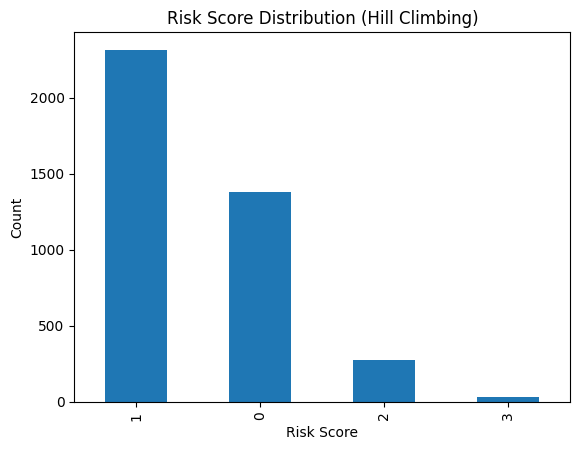

In [13]:
#RISK SCORE DISTRIBUTION
import matplotlib.pyplot as plt

plt.figure()
df['Risk_Score'].value_counts().plot(kind='bar')

plt.title("Risk Score Distribution (Hill Climbing)")
plt.xlabel("Risk Score")
plt.ylabel("Count")

plt.show()

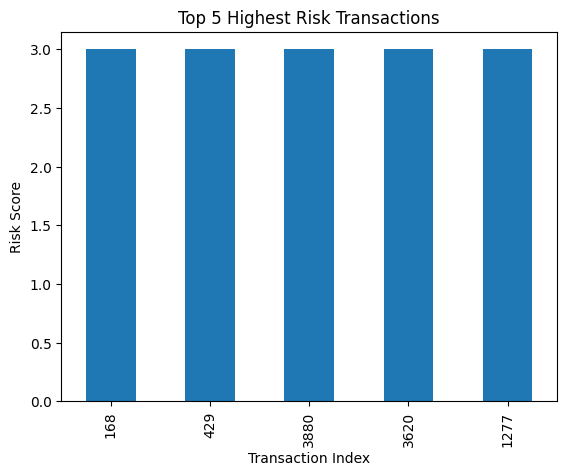

In [14]:
#TOP 5 HIGH RISK TRANSACTIONS
top5 = df.sort_values(by='Risk_Score', ascending=False).head(5)

plt.figure()
top5['Risk_Score'].plot(kind='bar')

plt.title("Top 5 Highest Risk Transactions")
plt.xlabel("Transaction Index")
plt.ylabel("Risk Score")

plt.show()

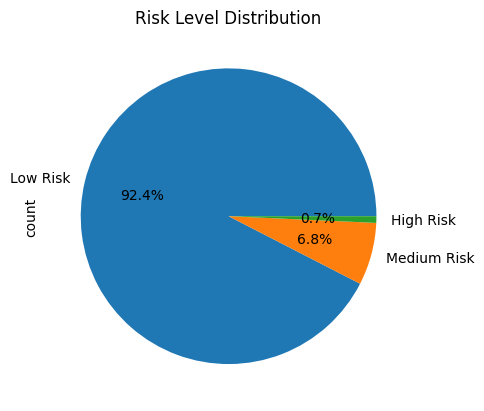

In [16]:
#PIE CHART (RISK LEVELS)
def risk_label(score):
    if score >= 3:
        return "High Risk"
    elif score == 2:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Level'] = df['Risk_Score'].apply(risk_label)
plt.figure()
df['Risk_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Risk Level Distribution")

plt.show()

In [ ]:
#FINAL CONCLUSION
Before applying AI -

the dataset only provided raw financial transaction data without
any method to identify the most suspicious or high-risk cases

Why AI was applied? -

From base paper

Problem:
Fraud/anomaly is not obvious
Requires identification of most risky transactions

AI techniques were applied to identify and focus on
the most suspicious transactions using optimization

Goal -

Find the highest risk (most fraudulent) transaction

That’s why AI technique used:
 Hill Climbing

AFTER APPLYING AI -
what the system does now?

For each transaction:

Calculates risk score
Compares with others
Moves toward higher risk
    
Output created -
Risk Score (0–4)
Identification of:
Most suspicious transaction
Top high-risk transactions

comparision:
Before AI                            After AI
   Raw data	                             Optimized result
   No focus	                             Identifies worst case
   Manual checking	                     Automated optimization
   No priority	                         High-risk prioritized

FINAL INTERPRETATION-
After applying Hill Climbing, the system was able to identify
the most suspicious transactions by iteratively moving toward
higher risk values. This demonstrates how AI optimization
techniques help in prioritizing and detecting critical fraud cases.